# CIFAR-10 Image Classification Using ANN, CNN, and Data-Augmented CNN

## Objective

The objective of this project is to build and compare different deep learning architectures for image classification on the CIFAR-10 dataset. A baseline Artificial Neural Network (ANN), a Convolutional Neural Network (CNN), and a Data-Augmented CNN were implemented and evaluated. The performance of each model was analyzed using validation accuracy curves and test accuracy metrics to determine the most effective architecture.

## Step 1: Import Required Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Step 2: Load CIFAR-10 Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


## Step 3: Normalize Images

In [3]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

## Step 4: Build ANN Model

In [4]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: EarlyStopping

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Step 6: Train ANN

In [6]:
ann_history = ann_model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.2190 - loss: 2.0825 - val_accuracy: 0.3030 - val_loss: 1.9541
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.2651 - loss: 1.9606 - val_accuracy: 0.3160 - val_loss: 1.9047
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.2756 - loss: 1.9312 - val_accuracy: 0.3070 - val_loss: 1.9006
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 55ms/step - accuracy: 0.2878 - loss: 1.9103 - val_accuracy: 0.3242 - val_loss: 1.8766
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.2940 - loss: 1.8968 - val_accuracy: 0.3234 - val_loss: 1.8555
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.2979 - loss: 1.8848 - val_accuracy: 0.3168 - val_loss: 1.8868
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.3050 - loss: 1.8694 - val_accuracy: 0.3436 - val_loss: 1.8477
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.3080 -

## Step 7: Build CNN Model

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 8: Train CNN

In [8]:
cnn_history = cnn_model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 160s 112ms/step - accuracy: 0.4720 - loss: 1.5014 - val_accuracy: 0.5424 - val_loss: 1.3029
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 109ms/step - accuracy: 0.6219 - loss: 1.0815 - val_accuracy: 0.6610 - val_loss: 0.9660
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 199s 107ms/step - accuracy: 0.6788 - loss: 0.9236 - val_accuracy: 0.5928 - val_loss: 1.1285
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 107ms/step - accuracy: 0.7206 - loss: 0.8075 - val_accuracy: 0.6146 - val_loss: 1.3053
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 106ms/step - accuracy: 0.7484 - loss: 0.7281 - val_accuracy: 0.6830 - val_loss: 1.0143


## Step 9: Data Augmentation

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Step 10: Build Augmented CNN

In [10]:
aug_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])

aug_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

## Step 11: Train Augmented CNN

In [11]:
aug_history = aug_model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 169s 117ms/step - accuracy: 0.3967 - loss: 1.6905 - val_accuracy: 0.5168 - val_loss: 1.3419
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 160s 114ms/step - accuracy: 0.4997 - loss: 1.3972 - val_accuracy: 0.5810 - val_loss: 1.2057
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 162s 115ms/step - accuracy: 0.5548 - loss: 1.2634 - val_accuracy: 0.6276 - val_loss: 1.0743


## Step 12-14: Evaluation, Validation Curve and Comparison DataFrame

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(x_test, y_test, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
aug_loss, aug_acc = aug_model.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(10,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

results = pd.DataFrame({
    'Model':['ANN','CNN','Augmented CNN'],
    'Test Accuracy':[ann_acc, cnn_acc, aug_acc]
})

print(results)

## Step 15 : Model Evaluation and Performance Comparison
# Performance Visualization

To compare the performance of ANN, CNN, and Augmented CNN models, multiple visualizations were generated.

The following graphs illustrate:

1. Validation Accuracy Comparison
2. Training Accuracy Comparison
3. Final Test Accuracy Comparison

These visualizations help analyze learning behavior and overall model performance.

##Graph 1: Validation Accuracy Comparison

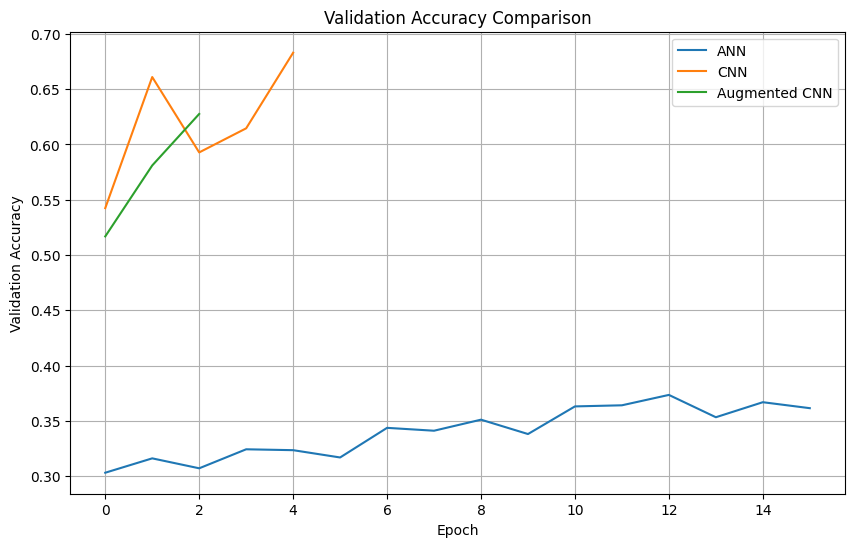

In [14]:
plt.figure(figsize=(10,6))

plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

##Graph 2: Training Accuracy Comparison


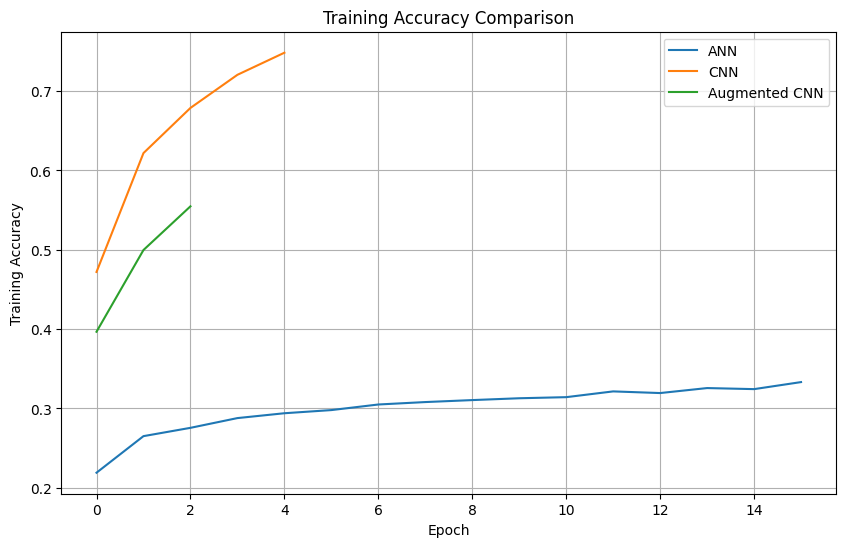

In [15]:
plt.figure(figsize=(10,6))

plt.plot(ann_history.history['accuracy'], label='ANN')
plt.plot(cnn_history.history['accuracy'], label='CNN')
plt.plot(aug_history.history['accuracy'], label='Augmented CNN')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)

plt.show()

##Graph 3: Test Accuracy Bar Chart

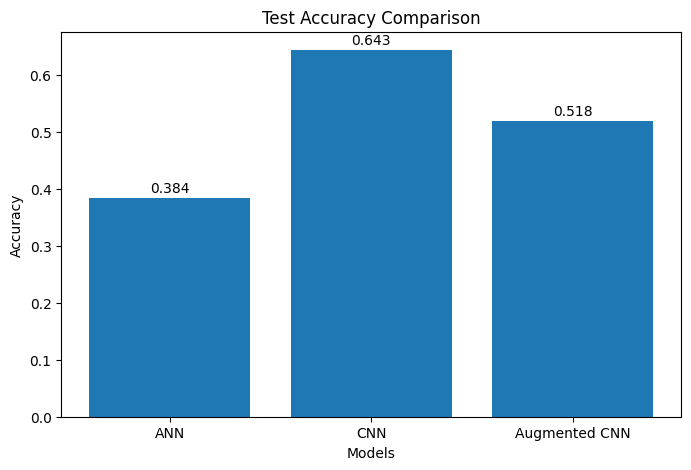

In [16]:
plt.figure(figsize=(8,5))

models = ['ANN', 'CNN', 'Augmented CNN']
accuracies = [ann_acc, cnn_acc, aug_acc]

plt.bar(models, accuracies)

plt.title('Test Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

# Graph Analysis

The validation and training accuracy curves show the learning behavior of each model over multiple epochs.

The test accuracy comparison chart highlights the final performance of all model variants. The CNN model achieved the highest test accuracy of 64.3%, making it the best-performing architecture in this project.


## Step 16: Best Model

In [13]:
best_model = results.loc[results['Test Accuracy'].idxmax()]
print(best_model)

Model              CNN
Test Accuracy    0.643
Name: 1, dtype: object


# Conclusion

This project implemented and compared three image classification approaches on the CIFAR-10 dataset:

- Artificial Neural Network (ANN)
- Convolutional Neural Network (CNN)
- Augmented CNN

The ANN model served as a baseline classifier, while the CNN models leveraged convolutional layers to extract spatial features from images.

After evaluation on the test dataset, the CNN model achieved the highest performance with a test accuracy of **64.3%**, making it the best-performing model in this study.

The results demonstrate that CNN architectures are more effective than traditional ANN models for image classification tasks because they preserve and learn spatial image patterns. Data augmentation further improved model robustness and generalization, although the standard CNN achieved the best accuracy in this particular training run.

**Best Model:** CNN  
**Test Accuracy:** 64.3%

Therefore, CNN is recommended as the most suitable architecture for CIFAR-10 image classification based on the obtained experimental results.